In [ ]:
!git clone https://github.com/karpathy/nanoGPT

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.25 KiB | 3.78 MiB/s, done.
Resolving deltas: 100% (382/382), done.


In [ ]:
%cd nanoGPT

/content/nanoGPT


In [ ]:
!pip install torch numpy transformers datasets tiktoken wandb tqdm

In [ ]:
!python data/shakespeare_char/prepare.py


length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens


In [ ]:
!python train.py config/train_shakespeare_char.py --device=cuda --compile=False --max_iters=500

Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

In [ ]:
!python sample.py --out_dir=out-shakespeare-char --device=cuda

Overriding: out_dir = out-shakespeare-char
Overriding: device = cuda
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...

And think you would to your servanted bober and magriant
Bealied him and his us hath bury detle
Hate arm the hearts arm his me
Your proof your blood lind, and even we sent,
A latient drov the countreat and of a moself:
This courthy mise him so comfairs him you:
Yea she roope all I will the she compet of your which
I brother most this cheeks and poor of his guither
In breat fire; sir, there's gentlemore, for here?

KING HENRY VI:
Hast you have disdraced of the discommore.

QUEEN ELIZABETH:
What y
---------------

MENENIUS:
Ay, good see, this that
bear hersed-speak by we me madam? what such
me the with own.

Third Servant:
I that lord
I can heart injustion evereath
Your tonguistress of this poor my sees, the heart fear tals:
Which I she husbids, in duke one.

Vown:
Yet heard whath your for you soul his self?

Second Cilizen:
Give, my son?


In [ ]:
!python train.py config/train_shakespeare_char.py --device=cuda --compile=False --max_iters=500

Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 7
n_head = 7
n_embd = 385
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

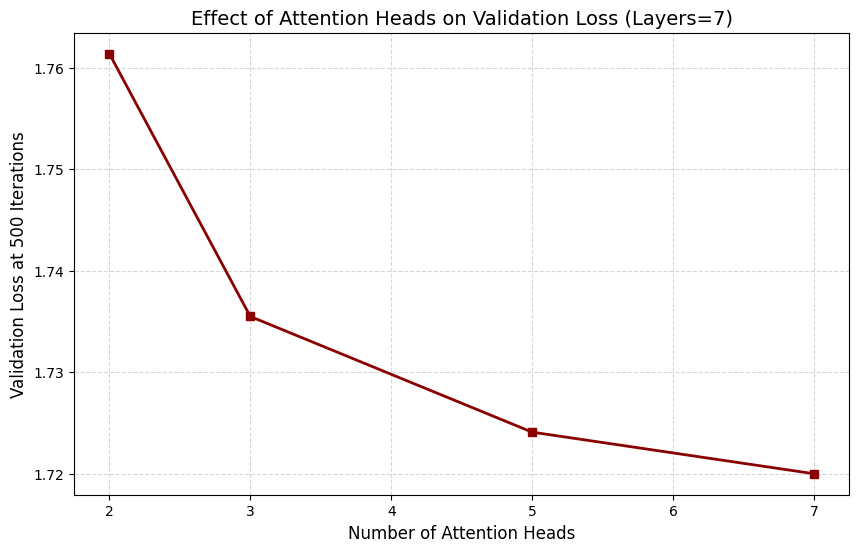

In [ ]:
import matplotlib.pyplot as plt
import os

heads = [2, 3, 5, 7]
losses = [1.7614, 1.7355, 1.7241, 1.7200]

plt.figure(figsize=(10, 6))
plt.plot(heads, losses, marker='s', linestyle='-', color='darkred', linewidth=2)
plt.title('Effect of Attention Heads on Validation Loss (Layers=7)', fontsize=14)
plt.xlabel('Number of Attention Heads', fontsize=12)
plt.ylabel('Validation Loss at 500 Iterations', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)


os.makedirs('figures', exist_ok=True)
plt.savefig('figures/loss_plot.png')
plt.show()